<a href="https://colab.research.google.com/github/zosiawidawska/Pliki/blob/main/DD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
### Zadanie 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection as skm
from matplotlib.pyplot import subplots
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import PredictionErrorDisplay
from imblearn.over_sampling import RandomOverSampler
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,
export_text)
from sklearn.metrics import (accuracy_score,
confusion_matrix,
ConfusionMatrixDisplay,
mean_squared_error)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)


In [20]:
### Zadanie 2
data = pd.read_csv("healthcare-dataset-stroke-data.csv")
2
nr_gr = 6.24
r_k = 2026
np.random.seed(int(nr_gr*r_k))
q = data.shape
idx = np.random.permutation(q[0]) #permutacja wierszy
data = data.iloc[idx[0:5000],:] #selekcja 5000 losowych wierszy
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
23,64778,Male,82.0,0,1,Yes,Private,Rural,208.30,32.5,Unknown,1
3160,26528,Female,17.0,0,0,No,Private,Rural,88.65,30.3,never smoked,0
1896,47972,Female,25.0,0,0,No,Govt_job,Rural,74.11,34.1,smokes,0
2771,11969,Female,50.0,0,0,Yes,Self-employed,Urban,110.18,26.0,formerly smoked,0
2899,33976,Male,55.0,0,0,Yes,Private,Urban,68.79,27.0,never smoked,0


In [21]:
### Zadanie 3
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 23 to 2992
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5000 non-null   int64  
 1   gender             5000 non-null   object 
 2   age                5000 non-null   float64
 3   hypertension       5000 non-null   int64  
 4   heart_disease      5000 non-null   int64  
 5   ever_married       5000 non-null   object 
 6   work_type          5000 non-null   object 
 7   Residence_type     5000 non-null   object 
 8   avg_glucose_level  5000 non-null   float64
 9   bmi                4803 non-null   float64
 10  smoking_status     5000 non-null   object 
 11  stroke             5000 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 507.8+ KB
None
                 id          age  hypertension  heart_disease  \
count   5000.000000  5000.000000   5000.000000     5000.00000   
mean   36481.636200    43.

In [8]:
### Zadanie 4
data = data.drop('id', axis=1)

In [9]:
### Zadanie 4 cd.
print("Duplikaty:", data.duplicated().sum())
data = data.drop_duplicates()

print("Brakujące wartości:\n", data.isnull().sum())
data = data.dropna(axis=0)

Duplikaty: 0
Brakujące wartości:
 gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  197
smoking_status         0
stroke                 0
dtype: int64


In [23]:
### Zadanie 5
data2 = pd.DataFrame()

for col in ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']:
    if col in data.columns:
        data2[col] = data[col]

data2['ever_married'] = np.int64(data['ever_married'] == 'Yes')
data2['Residence_type'] = np.int64(data['Residence_type'] == 'Urban')
data2['gender'] = np.int64(data['gender'] == 'Male')

data2['work_type_Private'] = np.int64(data['work_type'] == 'Private')
data2['work_type_Self_emp'] = np.int64(data['work_type'] == 'Self-employed')
data2['work_type_Govt_job'] = np.int64(data['work_type'] == 'Govt_job')
data2['work_type_children'] = np.int64(data['work_type'] == 'children')
data2['work_type_Never_worked'] = np.int64(data['work_type'] == 'Never_worked')

for status in data['smoking_status'].unique():
    data2[f'smoking_status_{status}'] = np.int64(data['smoking_status'] == status)

In [24]:
### Zadanie 6
X = data2.iloc[:, : -1]
y = data2.iloc[:, -1 :]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2,
random_state = 1)
3
dt = DTC(criterion='entropy', max_depth=5, random_state=1)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

Optymalne max_depth dla klasyfikacji: 3
Dokładność modelu w kroswalidacji: 1.0000


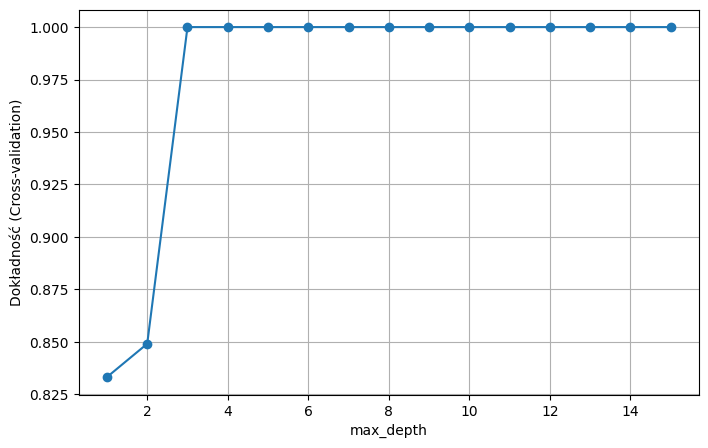

In [12]:
### Zadanie 7
max_depth_limit = 15
cw = np.zeros(max_depth_limit)

for i in range(max_depth_limit):
    dt_cv = DTC(criterion='entropy', max_depth=i+1, random_state=1)
    cw[i] = cross_val_score(dt_cv, X_train, y_train, cv=10).mean()

optimal_depth_clf = np.argmax(cw) + 1
print(f"Optymalne max_depth dla klasyfikacji: {optimal_depth_clf}")
print(f"Dokładność modelu w kroswalidacji: {cw[optimal_depth_clf-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, max_depth_limit + 1), cw, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Dokładność (Cross-validation)')
plt.grid()
plt.show()

Dokładność (Trening): 1.0
Dokładność (Test): 1.0


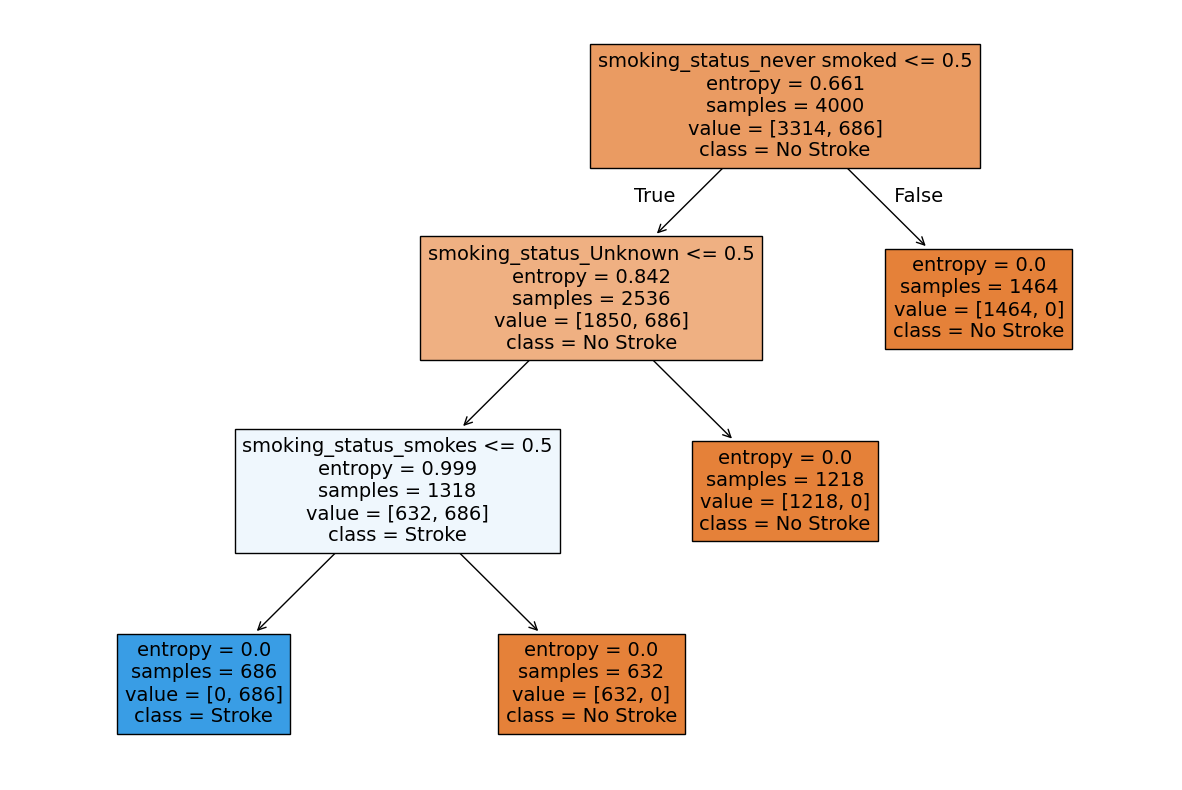

|--- smoking_status_never smoked <= 0.50
|   |--- smoking_status_Unknown <= 0.50
|   |   |--- smoking_status_smokes <= 0.50
|   |   |   |--- weights: [0.00, 686.00] class: 1
|   |   |--- smoking_status_smokes >  0.50
|   |   |   |--- weights: [632.00, 0.00] class: 0
|   |--- smoking_status_Unknown >  0.50
|   |   |--- weights: [1218.00, 0.00] class: 0
|--- smoking_status_never smoked >  0.50
|   |--- weights: [1464.00, 0.00] class: 0



In [26]:
### Zadanie 8
dt = DTC(criterion='entropy', max_depth=optimal_depth_clf, random_state=1)
dt.fit(X_train, y_train)

print("Dokładność (Trening):", accuracy_score(y_train, dt.predict(X_train)))
print("Dokładność (Test):", accuracy_score(y_test, dt.predict(X_test)))

ax = subplots(figsize=(15, 10))[1]
plot_tree(dt, feature_names=list(X.columns), filled=True, ax=ax, class_names=['No Stroke', 'Stroke'])
plt.show()

print(export_text(dt, feature_names=list(X.columns), show_weights=True))

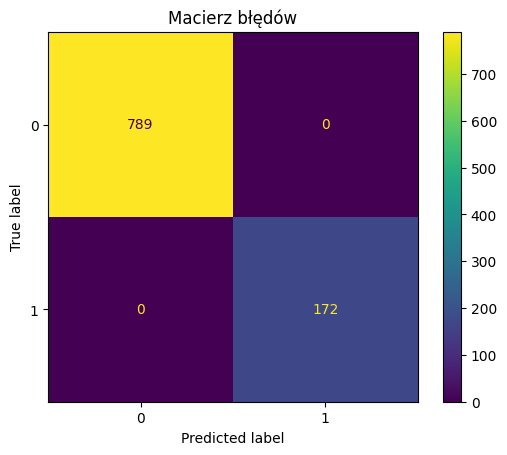

In [14]:
### Zadanie 9
cm = confusion_matrix(y_test, dt.predict(X_test), labels=dt.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot()
plt.title("Macierz błędów")
plt.show()

Optymalne max_depth - Oversampling: 3
Dokładność (Trening) z oversamplingiem: 1.0
Dokładność (Test) z oversamplingiem: 1.0


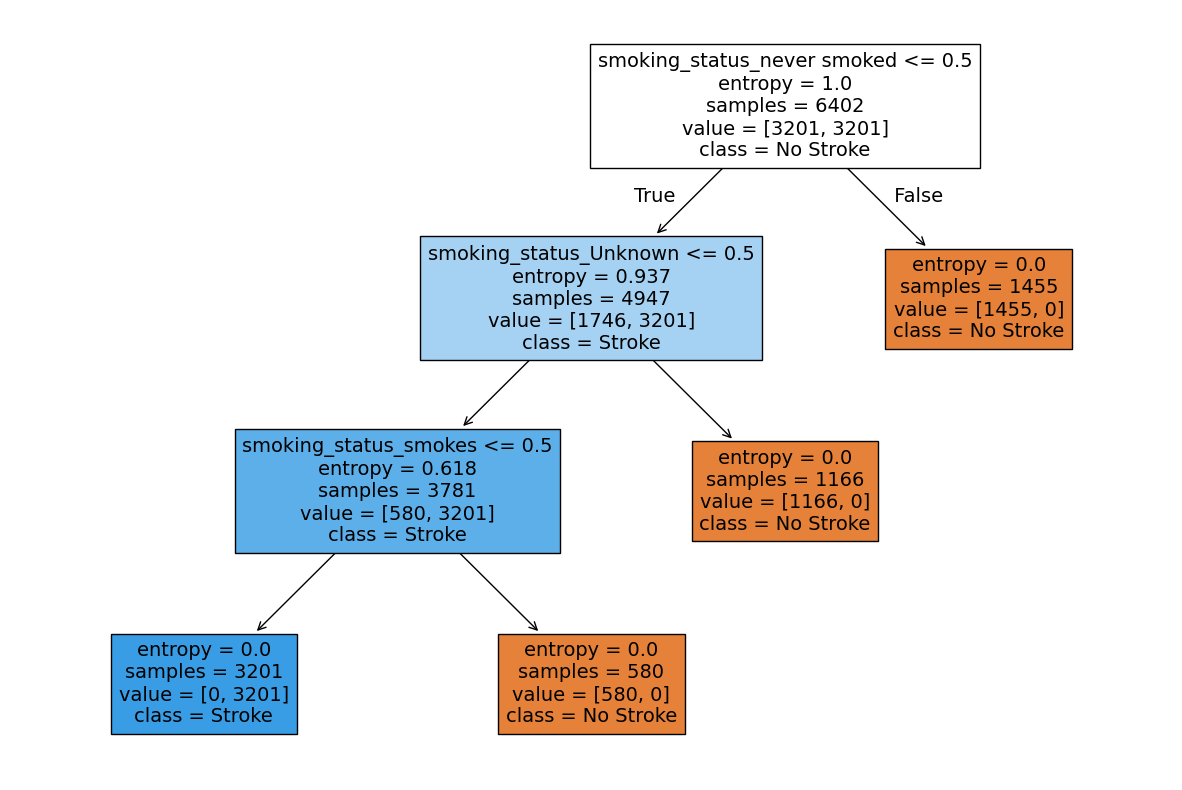

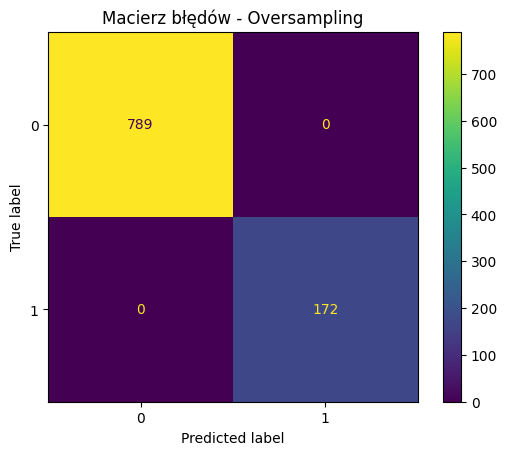

In [15]:
### Zadanie 10
ros = RandomOverSampler(random_state=1)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Zad. 7 - max_depth
cw_res = np.zeros(max_depth_limit)

for i in range(max_depth_limit):
    dt_cv_res = DTC(criterion='entropy', max_depth=i+1, random_state=1)
    cw_res[i] = cross_val_score(dt_cv_res, X_train_resampled, y_train_resampled, cv=10).mean()

optimal_depth_res = np.argmax(cw_res) + 1
print(f"Optymalne max_depth - Oversampling: {optimal_depth_res}")

# Zad. 8 - uczenie
dt_res = DTC(criterion='entropy', max_depth=optimal_depth_res, random_state=1)
dt_res.fit(X_train_resampled, y_train_resampled)

print("Dokładność (Trening) z oversamplingiem:", accuracy_score(y_train, dt_res.predict(X_train)))
print("Dokładność (Test) z oversamplingiem:", accuracy_score(y_test, dt_res.predict(X_test)))

ax = subplots(figsize=(15, 10))[1]
plot_tree(dt_res, feature_names=list(X.columns), filled=True, ax=ax, class_names=['No Stroke', 'Stroke'])
plt.show()

# Zad. 9 - macierz pomylek
cm_res = confusion_matrix(y_test, dt_res.predict(X_test), labels=dt_res.classes_)
disp_res = ConfusionMatrixDisplay(confusion_matrix=cm_res, display_labels=dt_res.classes_)
disp_res.plot()
plt.title("Macierz błędów - Oversampling")
plt.show()


Optymalne max_depth dla regresji: 2
MSE (Drzewo Regresyjne): 47.23418146282368


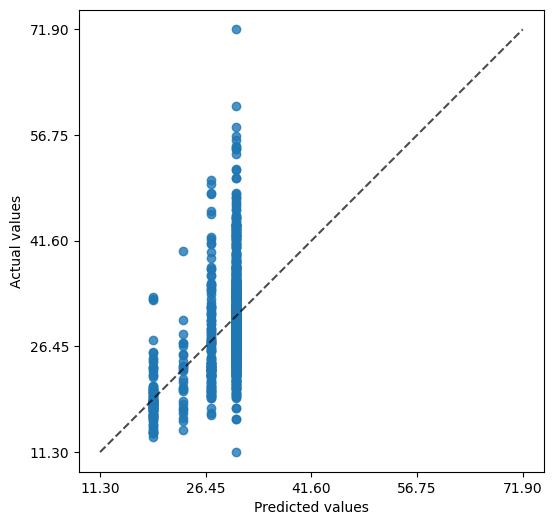

In [16]:
### Zadanie 11
X_reg = data2.drop('bmi', axis=1)
y_reg = data2['bmi']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_reg, y_reg, test_size=0.2, random_state=1)

cw_reg = np.zeros(max_depth_limit)

for i in range(max_depth_limit):
    dtr = DTR(criterion='squared_error', max_depth=i+1, random_state=1)
    cw_reg[i] = -cross_val_score(dtr, X_train2, y_train2, cv=10, scoring='neg_mean_squared_error').mean()

optimal_depth_reg = np.argmin(cw_reg) + 1
print(f"Optymalne max_depth dla regresji: {optimal_depth_reg}")

dtr_best = DTR(criterion='squared_error', max_depth=optimal_depth_reg, random_state=1)
dtr_best.fit(X_train2, y_train2)
y_pred_reg = dtr_best.predict(X_test2)

print("MSE (Drzewo Regresyjne):", mean_squared_error(y_test2, y_pred_reg))

ax = subplots(figsize=(6, 6))[1]
PredictionErrorDisplay.from_predictions(y_true=y_test2, y_pred=y_pred_reg, kind="actual_vs_predicted", ax=ax, random_state=0)
plt.show()

In [18]:
### Zadanie 12
num_features = X_train2.shape[1]
cw_rf = np.zeros(num_features)

for i in range(num_features):
    rf = RF(max_depth=optimal_depth_reg, max_features=i+1, random_state=1)
    cw_rf[i] = -cross_val_score(rf, X_train2, y_train2, cv=10, scoring='neg_mean_squared_error').mean()

optimal_mf = np.argmin(cw_rf) + 1
print(f"Optymalne max_features dla RandomForest: {optimal_mf}")

rf_best = RF(max_depth=optimal_depth_reg, max_features=optimal_mf, random_state=1)
rf_best.fit(X_train2, y_train2)
y_pred_rf = rf_best.predict(X_test2)
print("MSE (Random Forest):", mean_squared_error(y_test2, y_pred_rf))

Optymalne max_features dla RandomForest: 12
MSE (Random Forest): 46.137592834125584


In [28]:
### Zadanie 13
learning_rates = np.linspace(0.01, 0.1, 10)
cw_gbr = np.zeros(len(learning_rates))

for i in range(len(learning_rates)):
    gbr = GBR(max_depth=optimal_depth_reg, learning_rate=learning_rates[i], random_state=1)
    cw_gbr[i] = -cross_val_score(gbr, X_train2, y_train2, cv=10, scoring='neg_mean_squared_error').mean()

optimal_lr_idx = np.argmin(cw_gbr)
optimal_lr = learning_rates[optimal_lr_idx]
print(f"Optymalny learning_rate dla GradientBoosting: {optimal_lr:.3f}")

gbr_best = GBR(max_depth=optimal_depth_reg, learning_rate=optimal_lr, random_state=1)
gbr_best.fit(X_train2, y_train2)
y_pred_gbr = gbr_best.predict(X_test2)
print("MSE (Gradient Boosting):", mean_squared_error(y_test2, y_pred_gbr))

Optymalny learning_rate dla GradientBoosting: 0.050
MSE (Gradient Boosting): 43.210077933632135
